# 03 — Fama-French Factor Model

**Purpose:** Decompose each held ticker's returns into market (beta), size (SMB), value (HML), and genuine alpha. Flag which holdings are true alpha generators vs disguised beta.

**Depends on:** Nothing. Runs independently.

**Output:** `research/outputs/factor_state.json` (partial — Black-Litterman section added by NB 04)

**Sections:**
1. Setup & data
2. Fetch FF factors
3. Regressions — all held tickers
4. Visualisations
5. Export

In [1]:
import sys, os, json, logging
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

NOTEBOOK_DIR   = os.path.abspath('')
RESEARCH_ROOT  = os.path.join(NOTEBOOK_DIR, '..')
PORTFOLIO_ROOT = os.path.join(RESEARCH_ROOT, '..', '..', 'portfolio')
sys.path.insert(0, PORTFOLIO_ROOT)
sys.path.insert(0, RESEARCH_ROOT)

from src.config import (
    ASSET_UNIVERSE, BENCHMARK_TICKER, LOOKBACK_DAYS, RISK_FREE_RATE,
    FACTOR_MODEL_LOOKBACK, ALPHA_TSTAT_THRESHOLD, OUTPUT_FACTOR,
)
from src.factor_model import fetch_fama_french_factors, run_factor_regressions_all
from src.data_loader import fetch_historical, calculate_log_returns, fetch_fx_rate, convert_usd_prices_to_eur, load_ledger

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','axes.grid':True,'grid.alpha':0.3,'font.size':11})
print('✅ Imports OK')

✅ Imports OK


In [2]:
CACHE_PATH  = os.path.join(PORTFOLIO_ROOT, 'data', 'historical_prices.csv')
LEDGER_PATH = os.path.join(PORTFOLIO_ROOT, 'data', 'ledger.csv')

prices_raw  = fetch_historical(ASSET_UNIVERSE, LOOKBACK_DAYS, CACHE_PATH)
usd_eur     = fetch_fx_rate('USD', 'EUR')
prices      = convert_usd_prices_to_eur(prices_raw, usd_eur)
log_returns = calculate_log_returns(prices)
holdings, cash = load_ledger(LEDGER_PATH)
held_tickers   = [t for t in holdings.keys() if t in log_returns.columns]

start_date = str(log_returns.index[0].date())
end_date   = str(log_returns.index[-1].date())

print(f'✅ Data ready | {log_returns.shape} | {start_date} → {end_date}')
print(f'   Held tickers: {held_tickers}')

INFO: Fetching data for 102 assets from Yahoo Finance...


INFO: Data cached to C:\Users\ahmty\Desktop\hedge-fund\ml_quant_finance_research\general_research\notebooks\..\..\..\portfolio\data\historical_prices.csv (102/102 active tickers)


C:\Users\ahmty\Desktop\hedge-fund\ml_quant_finance_research\general_research\notebooks\..\..\..\portfolio\src\data_loader.py:177: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rate  = float(close.iloc[-1])   # .iloc[-1] avoids FutureWarning from float(Series)
INFO: FX Rate fetched: 1 USD = 0.8482 EUR


INFO:   Converted AMZN: USD → EUR @ 0.8482


INFO:   Converted NVDA: USD → EUR @ 0.8482


...

INFO:   Converted UPS: USD → EUR @ 0.8482


INFO:   Converted DE: USD → EUR @ 0.8482


INFO: Currency conversion applied to 62 non-EUR tickers.


INFO: Ledger loaded. Cash: €150.42, Holdings: 5 assets.


✅ Data ready | (425, 102) | 2024-09-13 → 2026-05-08
   Held tickers: ['APC.DE', 'MSF.DE', 'AMZN', 'TSLA', 'ATAI']


## 2. Fetch Fama-French factors

Fetched from Kenneth French's website via `pandas-datareader`. Requires internet.

In [3]:
ff_factors = fetch_fama_french_factors(start_date, end_date)

# Keep only dates present in our log_returns
ff_factors = ff_factors[ff_factors.index.isin(log_returns.index)]

print(f'FF factors: {ff_factors.shape}')
display(ff_factors.tail(5))

INFO: Fetching Fama-French 3-factor data from Kenneth French's website...


C:\Users\ahmty\Desktop\hedge-fund\ml_quant_finance_research\general_research\notebooks\..\src\factor_model.py:24: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench',


INFO: FF factors: 387 observations (2024-09-13 → 2026-03-31)


FF factors: (387, 4)


,Mkt-RF,SMB,HML,RF
Date,,,,
2026-03-25,0.0063,0.0069,0.0008,0.0001
2026-03-26,-0.0173,0.0007,0.0125,0.0001
2026-03-27,-0.0174,-0.0029,0.0071,0.0001
2026-03-30,-0.0044,-0.0072,0.0044,0.0001
2026-03-31,0.0298,0.0064,-0.0165,0.0001


## 3. Regressions — all held tickers

For each ticker: R_i - RF = α + β_mkt(Mkt-RF) + β_smb·SMB + β_hml·HML + ε

A t-stat > 2.0 on alpha → statistically significant alpha at 95% confidence.

In [4]:
# Run regressions
# If held_tickers is empty (no ledger), fall back to full universe sample
target_tickers = held_tickers if held_tickers else ASSET_UNIVERSE[:20]

factor_df = run_factor_regressions_all(
    log_returns, ff_factors, target_tickers, ALPHA_TSTAT_THRESHOLD
)

print(f'\n✅ Regressions complete for {len(factor_df)} tickers')
print(f'   Significant alpha (|t|>{ALPHA_TSTAT_THRESHOLD}): {factor_df["alpha_sig"].sum()}')
display(factor_df)

INFO: Factor regressions: 5 tickers | 0 with significant alpha



✅ Regressions complete for 5 tickers
   Significant alpha (|t|>2.0): 0


,ticker,annualised_alpha_pct,alpha_tstat,alpha_pvalue,beta_mkt,beta_smb,beta_hml,r_squared,alpha_sig,return_source,n_obs
0,ATAI,59.936,0.887,0.3759,1.1603,1.6163,-0.3061,0.1280,False,beta,387
1,TSLA,9.463,0.248,0.8044,2.1728,0.1481,-0.2451,0.4177,False,beta,387
2,APC.DE,-5.086,-0.237,0.8132,0.4400,-0.0459,0.3369,0.0705,False,mixed,387
3,AMZN,-5.851,-0.323,0.7469,1.2704,-0.0387,-0.3633,0.5355,False,beta,387
4,MSF.DE,-12.075,-0.590,0.5557,0.2033,-0.1036,-0.4179,0.0686,False,mixed,387


## 4. Visualisations

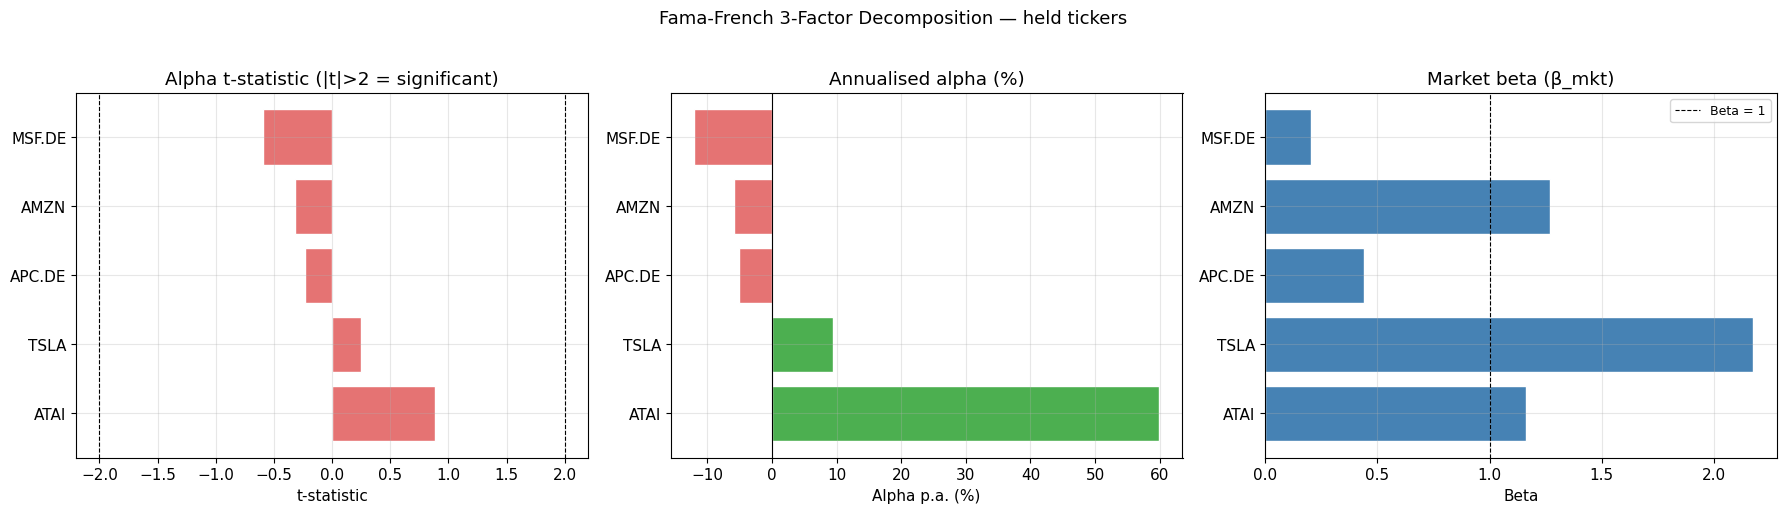

In [5]:
if factor_df.empty:
    print('No data to plot.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel 1: Alpha t-stat per ticker
    colors = ['#4CAF50' if sig else '#E57373' for sig in factor_df['alpha_sig']]
    axes[0].barh(factor_df['ticker'], factor_df['alpha_tstat'], color=colors, edgecolor='white')
    axes[0].axvline(ALPHA_TSTAT_THRESHOLD,  color='black', linestyle='--', linewidth=0.8)
    axes[0].axvline(-ALPHA_TSTAT_THRESHOLD, color='black', linestyle='--', linewidth=0.8)
    axes[0].set_title('Alpha t-statistic (|t|>2 = significant)')
    axes[0].set_xlabel('t-statistic')

    # Panel 2: Annualised alpha %
    axes[1].barh(factor_df['ticker'], factor_df['annualised_alpha_pct'],
                 color=['#4CAF50' if v > 0 else '#E57373' for v in factor_df['annualised_alpha_pct']],
                 edgecolor='white')
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_title('Annualised alpha (%)')
    axes[1].set_xlabel('Alpha p.a. (%)')

    # Panel 3: Market beta
    axes[2].barh(factor_df['ticker'], factor_df['beta_mkt'], color='steelblue', edgecolor='white')
    axes[2].axvline(1.0, color='black', linestyle='--', linewidth=0.8, label='Beta = 1')
    axes[2].set_title('Market beta (β_mkt)')
    axes[2].set_xlabel('Beta')
    axes[2].legend(fontsize=9)

    plt.suptitle('Fama-French 3-Factor Decomposition — held tickers', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

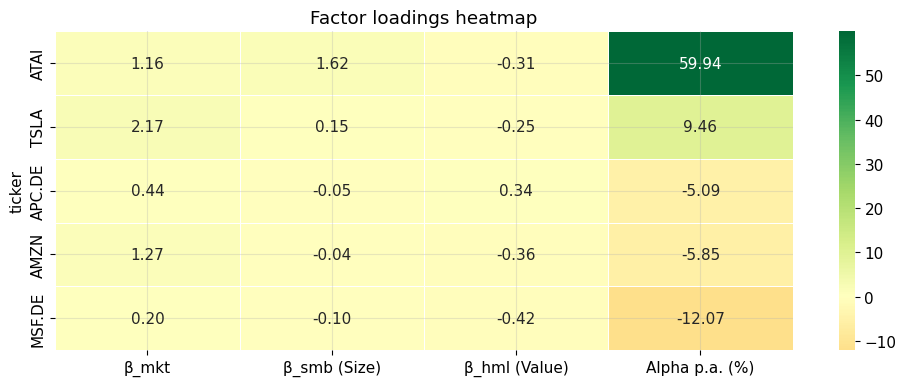

In [6]:
# Factor loading heatmap
if not factor_df.empty:
    import seaborn as sns
    heat = factor_df.set_index('ticker')[['beta_mkt','beta_smb','beta_hml','annualised_alpha_pct']].copy()
    heat.columns = ['β_mkt', 'β_smb (Size)', 'β_hml (Value)', 'Alpha p.a. (%)']
    fig, ax = plt.subplots(figsize=(10, max(4, len(heat)*0.5)))
    sns.heatmap(heat, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.4, ax=ax)
    ax.set_title('Factor loadings heatmap')
    plt.tight_layout()
    plt.show()

## 5. Export

Writes the factor regression results. The BL section (`bl_weights`, `bl_returns`) is added by `04_black_litterman.ipynb` which reads and updates this same file.

In [7]:
# Load existing factor_state if it exists (so BL data isn't overwritten)
existing = {}
if os.path.exists(OUTPUT_FACTOR):
    with open(OUTPUT_FACTOR, 'r') as f:
        existing = json.load(f)

state = {
    **existing,
    'generated_at':        datetime.now().isoformat(),
    'data_end_date':       end_date,
    'held_tickers':        held_tickers,
    'alpha_tstat_threshold': ALPHA_TSTAT_THRESHOLD,
    'factor_regressions':  factor_df.where(pd.notna(factor_df), None).to_dict(orient='records') if not factor_df.empty else [],
    'summary': {
        'n_tickers_regressed':   len(factor_df),
        'n_significant_alpha':   int(factor_df['alpha_sig'].sum()) if not factor_df.empty else 0,
        'avg_market_beta':       round(float(factor_df['beta_mkt'].mean()), 4) if not factor_df.empty else None,
        'avg_alpha_pct':         round(float(factor_df['annualised_alpha_pct'].mean()), 3) if not factor_df.empty else None,
    }
}

os.makedirs(os.path.dirname(OUTPUT_FACTOR), exist_ok=True)
with open(OUTPUT_FACTOR, 'w', encoding='utf-8') as f:
    json.dump(state, f, indent=2, default=str)

print(f'✅ Exported → {OUTPUT_FACTOR}  ({os.path.getsize(OUTPUT_FACTOR)/1024:.1f} KB)')
print(f'   Now run 04_black_litterman.ipynb to add BL weights to this file.')

✅ Exported → C:\Users\ahmty\Desktop\hedge-fund\ml_quant_finance_research\general_research\notebooks\..\src\..\outputs\factor_state.json  (3.6 KB)
   Now run 04_black_litterman.ipynb to add BL weights to this file.
